In [3]:
import os
import re
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import partial_r as pr
from pathlib import Path
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import regression_functions as rf
from scipy.stats import linregress
from scipy.stats import gaussian_kde
from matplotlib.backends.backend_pdf import PdfPages
from figure_formatting import setup_figure, save_figure
from regression_functions import run_model_comparison as run_model

importlib.reload(rf)
importlib.reload(pr)

<module 'partial_r' from '/Users/bmacedo/Desktop/final_WM/code/partial_r.py'>

### Read in the data 

From `covbat_harmonization_ses.Rmd` followed by `abcd_prep_harmonized_dfs`

In [4]:
ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
RESULTS_DIR = ROOT_DIR / "output_data" / "results"

dfA_macro = pd.read_csv(RESULTS_DIR / "dfA_macro_cog_12_10.csv")
dfB_macro = pd.read_csv(RESULTS_DIR / "dfB_macro_cog_12_10.csv")

dfA_NODDI = pd.read_csv(RESULTS_DIR / "dfA_NODDI_cog_12_10.csv")
dfB_NODDI = pd.read_csv(RESULTS_DIR / "dfB_NODDI_cog_12_10.csv")

dfA_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_NODDI_cog_12_10.csv")
dfB_macro_plus_NODDI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_NODDI_cog_12_10.csv")

dfA_DKI = pd.read_csv(RESULTS_DIR / "dfA_DKI_cog_12_10.csv")
dfB_DKI = pd.read_csv(RESULTS_DIR / "dfB_DKI_cog_12_10.csv")

dfA_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfA_macro_plus_DKI_cog_12_10.csv")
dfB_macro_plus_DKI = pd.read_csv(RESULTS_DIR / "dfB_macro_plus_DKI_cog_12_10.csv")

In [5]:
print(dfA_macro.shape)
dfA_macro["matched_group"].value_counts()

(7877, 1139)


matched_group
2    3956
1    3921
Name: count, dtype: int64

In [6]:
tracts = sorted(set(re.match(r"^msmt_([^_]+)_[^_]+$", c).group(1)
    for c in dfA_macro.columns
    if c.startswith("msmt_") and re.match(r"^msmt_([^_]+)_[^_]+$", c)))

In [7]:
metrics = sorted(set(re.match(r"^msmt_[^_]+_(.+)$", c).group(1)   # capture everything after 2nd underscore
    for c in dfA_macro.columns
    if re.match(r"^msmt_[^_]+_(.+)$", c)))

### Cognition - SES relationship
### Mutlivariate Global Ridge Regression

NODDI as primary model, DKI as sensitivity analysis

Includes sensitivity analyses with brain volume correction (eTIV)

In [8]:
ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
FIG5_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure5"
SUPPFIG10_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig10"
MODEL_DIR = ROOT_DIR / "output_data" / "model_outputs"
for d in [FIG5_DIR, SUPPFIG10_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

cache_path = ROOT_DIR / "output_data" / "results" / "cached_results.pkl"
permutations = 1

scenarios = [("NODDI", False, dfA_macro_plus_NODDI, dfB_macro_plus_NODDI, FIG5_DIR),
             ("NODDI", True, dfA_macro_plus_NODDI, dfB_macro_plus_NODDI, SUPPFIG10_DIR)]

tests = [("Cognition", "neurocog_pc1.bl", "base"), ("Cognition above General Exposome", "neurocog_pc1.bl", "SES"),
         ("General Exposome", "General_SES", "base"), ("General Exposome above Cognition", "General_SES", "Cog")]

results = {(name, include_etiv): {} for name, include_etiv, _, _, _ in scenarios}

for name, include_etiv, df_A, df_B, save_dir in scenarios:
    print(f"\n=== Running condition: {name} {'+eTIV' if include_etiv else ''} ===")
    for test_name, target_var, conf_type in tests:

        base_conf = ["age", "sex", "qc_prediction"]
        if include_etiv: base_conf += ["estimated_brain_volume"]

        if conf_type == "SES": conf = base_conf + ["General_SES"]
        elif conf_type == "Cog": conf = base_conf + ["neurocog_pc1.bl"]
        else: conf = base_conf

        features = [c for c in df_A.columns if c.startswith("msmt_")]
        print(f"  → {test_name}: target={target_var}, confounds={conf}")

        perf, haufe = rf.run_model_comparison(features_subset=features,
                                              df_A=df_A, df_B=df_B, target=target_var, output_dir=MODEL_DIR,
                                              confounds=conf, model_type='ridge')
        results[(name, include_etiv)][test_name] = perf


=== Running condition: NODDI  ===
  → Cognition: target=neurocog_pc1.bl, confounds=['age', 'sex', 'qc_prediction']
  → Cognition above General Exposome: target=neurocog_pc1.bl, confounds=['age', 'sex', 'qc_prediction', 'General_SES']
  → General Exposome: target=General_SES, confounds=['age', 'sex', 'qc_prediction']
  → General Exposome above Cognition: target=General_SES, confounds=['age', 'sex', 'qc_prediction', 'neurocog_pc1.bl']

=== Running condition: NODDI +eTIV ===
  → Cognition: target=neurocog_pc1.bl, confounds=['age', 'sex', 'qc_prediction', 'estimated_brain_volume']
  → Cognition above General Exposome: target=neurocog_pc1.bl, confounds=['age', 'sex', 'qc_prediction', 'estimated_brain_volume', 'General_SES']
  → General Exposome: target=General_SES, confounds=['age', 'sex', 'qc_prediction', 'estimated_brain_volume']
  → General Exposome above Cognition: target=General_SES, confounds=['age', 'sex', 'qc_prediction', 'estimated_brain_volume', 'neurocog_pc1.bl']


In [10]:
colors_disc = ["#5D3FD3", "#5D3FD3", "#0033A0", "#0033A0"]
colors_repl = ["#B8A6F9", "#B8A6F9", "#7BA6E6", "#7BA6E6"]

scenario_configs = [("NODDI", False, FIG5_DIR, "Main"),
                    ("NODDI", True, SUPPFIG10_DIR, "Supplement_TBV")]

ordered_tests = [("Cognition", "neurocog_pc1.bl"),
                 ("Cognition above General Exposome", "neurocog_pc1.bl"),
                 ("General Exposome", "General_SES"),
                 ("General Exposome above Cognition", "General_SES")]


[SCENARIO] Main
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/main_figures/figure5/NODDI_eTIV_panels.svg
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/main_figures/figure5/NODDI_eTIV_panels.png


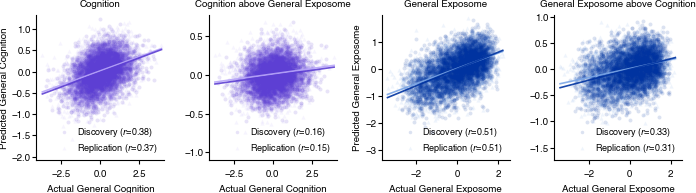


[SCENARIO] Supplement_TBV
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/supplemental_figures/suppfig10/NODDI_eTIV_panels_brain_vol.svg
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/supplemental_figures/suppfig10/NODDI_eTIV_panels_brain_vol.png


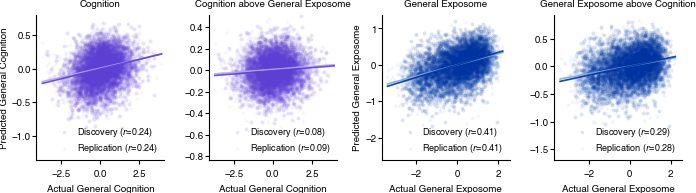

In [11]:
W_MM = 180
H_MM = 54 

for name, include_etiv, save_dir, tag in scenario_configs:
    scenario_key = (name, include_etiv)
    print(f"\n[SCENARIO] {tag}")

    fig, axes = setup_figure(width_mm=W_MM, height_mm=H_MM, margins_mm=(10, 6, 10, 7), nrows=1, ncols=4,
                             sharex=False, sharey=False, axes_linewidth=0.8, base_pt=7, label_pt=7, title_pt=7)
    fig.subplots_adjust(wspace=0.35)

    for ax_idx, (ax, (test_name, target_var)) in enumerate(zip(axes, ordered_tests)):
        perf = results[scenario_key][test_name]
        y_true_A = perf["y_true_A"]; y_pred_A = perf["y_pred_A"]
        y_true_B = perf["y_true_B"]; y_pred_B = perf["y_pred_B"]

        if target_var == "neurocog_pc1.bl": display_var = "General Cognition"
        elif target_var == "General_SES": display_var = "General Exposome"
        else: display_var = target_var.replace("_", " ")

        color_d = colors_disc[ax_idx]; color_r = colors_repl[ax_idx]

        ax.scatter(y_true_B, y_pred_B, color=color_r, alpha=0.12, s=9, marker="^", linewidths=0,
                   label=f"Replication ($r$={perf['r_B']:.2f})", zorder=2, rasterized=True)
        ax.scatter(y_true_A, y_pred_A, color=color_d, alpha=0.14, s=8, marker="o", linewidths=0,
                   label=f"Discovery ($r$={perf['r_A']:.2f})", zorder=3, rasterized=True)

        min_val = float(min(y_true_A.min(), y_pred_A.min(), y_true_B.min(), y_pred_B.min()))
        max_val = float(max(y_true_A.max(), y_pred_A.max(), y_true_B.max(), y_pred_B.max()))

        sA, iA = np.polyfit(y_true_A, y_pred_A, 1)
        sB, iB = np.polyfit(y_true_B, y_pred_B, 1)

        ax.plot([min_val, max_val], [sB * min_val + iB, sB * max_val + iB], color=color_r, lw=1.2, alpha=0.9, zorder=4)
        ax.plot([min_val, max_val], [sA * min_val + iA, sA * max_val + iA], color=color_d, lw=1.2, alpha=0.9, zorder=4)

        x_combined = np.concatenate([y_true_A, y_true_B])
        y_combined = np.concatenate([y_pred_A, y_pred_B])

        buffer = 0.05
        x_low, x_high = np.percentile(x_combined, [buffer, 100 - buffer])
        y_low, y_high = np.percentile(y_combined, [buffer, 100 - buffer])

        pad_x = 0.10 * (x_high - x_low)
        pad_y = 0.10 * (y_high - y_low)
        legend_pad = 0.30 * (y_high - y_low)

        ax.set_xlim(x_low - pad_x, x_high + pad_x)
        ax.set_ylim((y_low - pad_y) - legend_pad, y_high + pad_y)

        ax.set_facecolor("white")
        ax.set_title(test_name, pad=6)
        ax.set_xlabel(f"Actual {display_var}")

        if ax_idx in (0, 2):
            ax.set_ylabel(f"Predicted {display_var}")
            ax.yaxis.labelpad = 2
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="y", pad=1)
        ax.tick_params(axis="both", width=0.8, length=3, direction="out")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        handles, labels = ax.get_legend_handles_labels()
        order = [labels.index(next(l for l in labels if l.startswith("Discovery"))),
                 labels.index(next(l for l in labels if l.startswith("Replication")))]

        ax.legend([handles[i] for i in order], [labels[i] for i in order], frameon=True,
                  facecolor="white", framealpha=0.0, edgecolor="none", fontsize=6.5, loc="lower right",
                  borderpad=0.2, labelspacing=0.25, handletextpad=0.4, markerscale=0.9)

    if include_etiv:
        file_stub = "NODDI_eTIV_panels_brain_vol"
    else:
        file_stub = "NODDI_eTIV_panels"

    save_figure(fig, save_dir / f"{file_stub}.svg", autofit=False)
    fig.savefig(save_dir / f"{file_stub}.png", dpi=600, bbox_inches="tight")
    print(f"[SAVE] → {save_dir / f'{file_stub}.svg'}")
    print(f"[SAVE] → {save_dir / f'{file_stub}.png'}")
    plt.show()

In [12]:
ses_covariates = ["age", "sex", "qc_prediction", "General_SES"]
cog_covariates = ["age", "sex", "qc_prediction", "neurocog_pc1.bl"]
combined_covariates = ["age", "sex", "qc_prediction", "General_SES", "neurocog_pc1.bl"]

ROOT_DIR = Path("/Users/bmacedo/Desktop/final_WM")
FIG5_DIR = ROOT_DIR / "output_data" / "results" / "main_figures" / "figure5"
SUPPFIG10_DIR = ROOT_DIR / "output_data" / "results" / "supplemental_figures" / "suppfig10"
for d in [FIG5_DIR, SUPPFIG10_DIR]: d.mkdir(parents=True, exist_ok=True)

scenarios = [("NODDI", False, dfA_macro_plus_NODDI, dfB_macro_plus_NODDI, FIG5_DIR),
             ("NODDI", True, dfA_macro_plus_NODDI, dfB_macro_plus_NODDI, SUPPFIG10_DIR)]

alpha_levels = [0.05, 0.01, 0.001]
cmap = sns.color_palette("viridis", as_cmap=True)

partial_r_results = {}

for name, include_etiv, df_A, df_B, save_dir in scenarios:

    print(f"\nRunning partial r models for {name}, include_etiv={include_etiv}")
    msmt_cols = [c for c in df_A.columns if c.startswith("msmt_")]

    # cognition only
    dfA_cog = pr.run_partial_r(df_A, msmt_cols, cog_covariates, include_etiv, target_cov="neurocog_pc1.bl")
    dfB_cog = pr.run_partial_r(df_B, msmt_cols, cog_covariates, include_etiv, target_cov="neurocog_pc1.bl")

    # cognition above exposome
    dfA_cog_plus_SES = pr.run_partial_r(df_A, msmt_cols, combined_covariates, include_etiv, target_cov="neurocog_pc1.bl")
    dfB_cog_plus_SES = pr.run_partial_r(df_B, msmt_cols, combined_covariates, include_etiv, target_cov="neurocog_pc1.bl")

    # exposome only
    dfA_ses = pr.run_partial_r(df_A, msmt_cols, ses_covariates, include_etiv, target_cov="General_SES")
    dfB_ses = pr.run_partial_r(df_B, msmt_cols, ses_covariates, include_etiv, target_cov="General_SES")

    # exposome above cognition
    dfA_ses_plus_cog = pr.run_partial_r(df_A, msmt_cols, combined_covariates, include_etiv, target_cov="General_SES")
    dfB_ses_plus_cog = pr.run_partial_r(df_B, msmt_cols, combined_covariates, include_etiv, target_cov="General_SES")

    # store everything
    partial_r_results[(name, include_etiv, "A_COG")] = dfA_cog
    partial_r_results[(name, include_etiv, "B_COG")] = dfB_cog
    partial_r_results[(name, include_etiv, "A_COG_SES")] = dfA_cog_plus_SES
    partial_r_results[(name, include_etiv, "B_COG_SES")] = dfB_cog_plus_SES
    partial_r_results[(name, include_etiv, "A_SES")] = dfA_ses
    partial_r_results[(name, include_etiv, "B_SES")] = dfB_ses
    partial_r_results[(name, include_etiv, "A_SES_COG")] = dfA_ses_plus_cog
    partial_r_results[(name, include_etiv, "B_SES_COG")] = dfB_ses_plus_cog

    etiv_str = "_WithETIV" if include_etiv else "_NoETIV"

    dfA_cog.to_csv(save_dir / f"PartialR_{name}{etiv_str}_A_COG.csv", index=False)
    dfB_cog.to_csv(save_dir / f"PartialR_{name}{etiv_str}_B_COG.csv", index=False)
    dfA_cog_plus_SES.to_csv(save_dir / f"PartialR_{name}{etiv_str}_A_COGplusSES.csv", index=False)
    dfB_cog_plus_SES.to_csv(save_dir / f"PartialR_{name}{etiv_str}_B_COGplusSES.csv", index=False)

    dfA_ses.to_csv(save_dir / f"PartialR_{name}{etiv_str}_A_SES.csv", index=False)
    dfB_ses.to_csv(save_dir / f"PartialR_{name}{etiv_str}_B_SES.csv", index=False)
    dfA_ses_plus_cog.to_csv(save_dir / f"PartialR_{name}{etiv_str}_A_SESplusCOG.csv", index=False)
    dfB_ses_plus_cog.to_csv(save_dir / f"PartialR_{name}{etiv_str}_B_SESplusCOG.csv", index=False)

    print(f"[SAVE] partial r outputs → {save_dir}")


Running partial r models for NODDI, include_etiv=False
[SAVE] partial r outputs → /Users/bmacedo/Desktop/final_WM/output_data/results/main_figures/figure5

Running partial r models for NODDI, include_etiv=True
[SAVE] partial r outputs → /Users/bmacedo/Desktop/final_WM/output_data/results/supplemental_figures/suppfig10



[SCENARIO] Main
Unadjusted r: [-0.157, 0.285]
Adjusted r:   [-0.054, 0.146]
Delta r:      [-0.139, 0.102]
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/main_figures/figure5/PartialR_Cognition_ABC.svg
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/main_figures/figure5/PartialR_Cognition_ABC.png


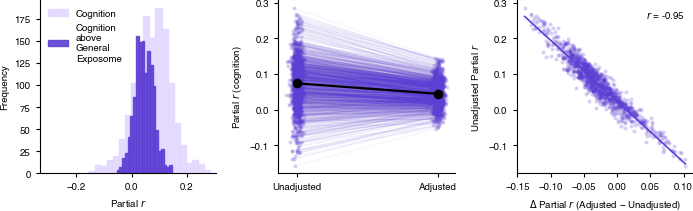


[SCENARIO] Supplement_TBV
Unadjusted r: [-0.108, 0.083]
Adjusted r:   [-0.039, 0.054]
Delta r:      [-0.065, 0.075]
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/supplemental_figures/suppfig10/PartialR_Cognition_ABC_w_ETIV.svg
[SAVE] → /Users/bmacedo/Desktop/final_WM/output_data/results/supplemental_figures/suppfig10/PartialR_Cognition_ABC_w_ETIV.png


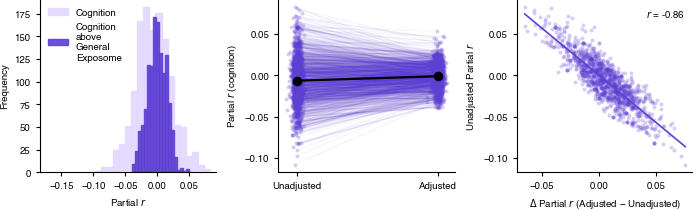

In [13]:
cog_light = "#E3D8FF"
cog_dark = "#5D3FD3"

scenario_configs = [("NODDI", False, FIG5_DIR, "Main"),
                    ("NODDI", True, SUPPFIG10_DIR, "Supplement_TBV")]

for name, include_etiv, save_dir, tag in scenario_configs:
    cog_r = partial_r_results[(name, include_etiv, "A_COG")]["partial_r"].values
    cogSES_r = partial_r_results[(name, include_etiv, "A_COG_SES")]["partial_r"].values
    ses_r = partial_r_results[(name, include_etiv, "A_SES")]["partial_r"].values
    sesCog_r = partial_r_results[(name, include_etiv, "A_SES_COG")]["partial_r"].values

    r_unadj = cog_r
    r_adj = cogSES_r
    delta_r = r_adj - r_unadj

    W_MM = 180
    H_MM = 60
    fig, axes = setup_figure(width_mm=W_MM, height_mm=H_MM, margins_mm=(11, 3, 10, 6), nrows=1, ncols=3, sharex=False, sharey=False, axes_linewidth=0.8, base_pt=7, label_pt=7, title_pt=7)
    fig.subplots_adjust(wspace=0.35)

    # =========================
    # PANEL A — Histogram
    # =========================
    ax = axes[0]
    bins = 20
    alpha = 0.9

    h1 = ax.hist(r_unadj, bins=bins, alpha=alpha, color=cog_light, edgecolor=cog_light, label="Cognition")
    h2 = ax.hist(r_adj, bins=bins, alpha=alpha, color=cog_dark, edgecolor=cog_dark, label="Cognition\nabove\nGeneral\nExposome")

    hist_max = float(max(np.max(h1[0]), np.max(h2[0])))
    xs = np.linspace(float(min(r_unadj.min(), r_adj.min())), float(max(r_unadj.max(), r_adj.max())), 400)

    k1 = gaussian_kde(r_unadj)
    k2 = gaussian_kde(r_adj)
    y1 = k1(xs)
    y2 = k2(xs)
    if y1.max() > 0: y1 = y1 / y1.max() * hist_max
    if y2.max() > 0: y2 = y2 / y2.max() * hist_max

    xlo = float(min(r_unadj.min(), r_adj.min()))
    xhi = float(max(r_unadj.max(), r_adj.max()))
    xr = xhi - xlo

    ax.set_xlim(xlo - 0.40 * xr, xhi + 0.05 * xr)
    ax.set_xlabel(r"Partial $r$")
    ax.set_ylabel("Frequency")
    ax.tick_params(width=0.8, length=3, direction="out")
    sns.despine(ax=ax, top=True, right=True)
    ax.legend(frameon=False, loc="upper left")

    # =========================
    # PANEL B — Paired plot
    # =========================
    ax = axes[1]
    rng = np.random.default_rng(0)
    jitter = rng.normal(0, 0.02, size=len(r_unadj))

    x_left = np.ones_like(r_unadj) * 1 + jitter
    x_right = np.ones_like(r_adj) * 2 + jitter

    for xl, xr_, ru, ra in zip(x_left, x_right, r_unadj, r_adj):
        ax.plot([xl, xr_], [ru, ra], color=cog_dark, alpha=0.06, lw=0.8)

    ax.scatter(x_left, r_unadj, s=8, color=cog_dark, alpha=0.25, linewidths=0, rasterized=True)
    ax.scatter(x_right, r_adj, s=8, color=cog_dark, alpha=0.25, linewidths=0, rasterized=True)

    mu_unadj = float(np.mean(r_unadj))
    mu_adj = float(np.mean(r_adj))
    ax.scatter(1, mu_unadj, color="black", marker="o", s=35, zorder=3)
    ax.scatter(2, mu_adj, color="black", marker="o", s=35, zorder=3)
    ax.plot([1, 2], [mu_unadj, mu_adj], color="black", lw=1.6)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Unadjusted", "Adjusted"])
    ax.set_ylabel(r"Partial $r$ (cognition)")
    sns.despine(ax=ax, top=True, right=True)
    ax.tick_params(width=0.8, length=3, direction="out")

    # =========================
    # PANEL C — Change vs Original
    # =========================
    ax = axes[2]
    ax.scatter(delta_r, r_unadj, s=8, color=cog_dark, alpha=0.25, linewidths=0, rasterized=True)

    s, i, rv, _, _ = linregress(delta_r, r_unadj)
    xs2 = np.linspace(float(delta_r.min()), float(delta_r.max()), 300)
    ax.plot(xs2, s * xs2 + i, color=cog_dark, lw=1.2)

    ax.set_xlabel(r"$\Delta$ Partial $r$ (Adjusted − Unadjusted)")
    ax.set_ylabel(r"Unadjusted Partial $r$")
    ax.text(0.95, 0.95, rf"$r$ = {rv:.2f}", transform=ax.transAxes, ha="right", va="top", fontsize=7)

    sns.despine(ax=ax, top=True, right=True)
    ax.tick_params(width=0.8, length=3, direction="out")

    print(f"\n[SCENARIO] {tag}")
    print(f"Unadjusted r: [{r_unadj.min():.3f}, {r_unadj.max():.3f}]")
    print(f"Adjusted r:   [{r_adj.min():.3f}, {r_adj.max():.3f}]")
    print(f"Delta r:      [{delta_r.min():.3f}, {delta_r.max():.3f}]")

    file_stub = "PartialR_Cognition_ABC_w_ETIV" if include_etiv else "PartialR_Cognition_ABC"
    save_figure(fig, save_dir / f"{file_stub}.svg", autofit=False)
    fig.savefig(save_dir / f"{file_stub}.png", dpi=600, bbox_inches="tight")

    print(f"[SAVE] → {save_dir / f'{file_stub}.svg'}")
    print(f"[SAVE] → {save_dir / f'{file_stub}.png'}")
    plt.show()